In [49]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from skbio import DistanceMatrix
from skbio.stats.ordination import pcoa


In [66]:
HAS_GROUPS = True
WORKDIR = '/home/p/code/codon_usage'

# QC

to evaluate assembly and remove bad samples:

``` sh
$ seqkit stats -a *.fasta > ../asembly_stats.tsv
```

If samples belong to different groups, the group label can be added as a prefix in the file name. For example: `group1_ecoli.fasta`

In [67]:
target_metrics = ['num_seqs','N50','N50_num', 'GC(%)',]
n_metrics = len(target_metrics)
ncols = 2
nrows = math.ceil(n_metrics / ncols)

In [4]:
qc_df = pd.read_csv(f'{WORKDIR}/asembly_stats.tsv', sep=r'\s+')
qc_df['N50'] = qc_df['N50'].str.replace(',', '').astype(int)

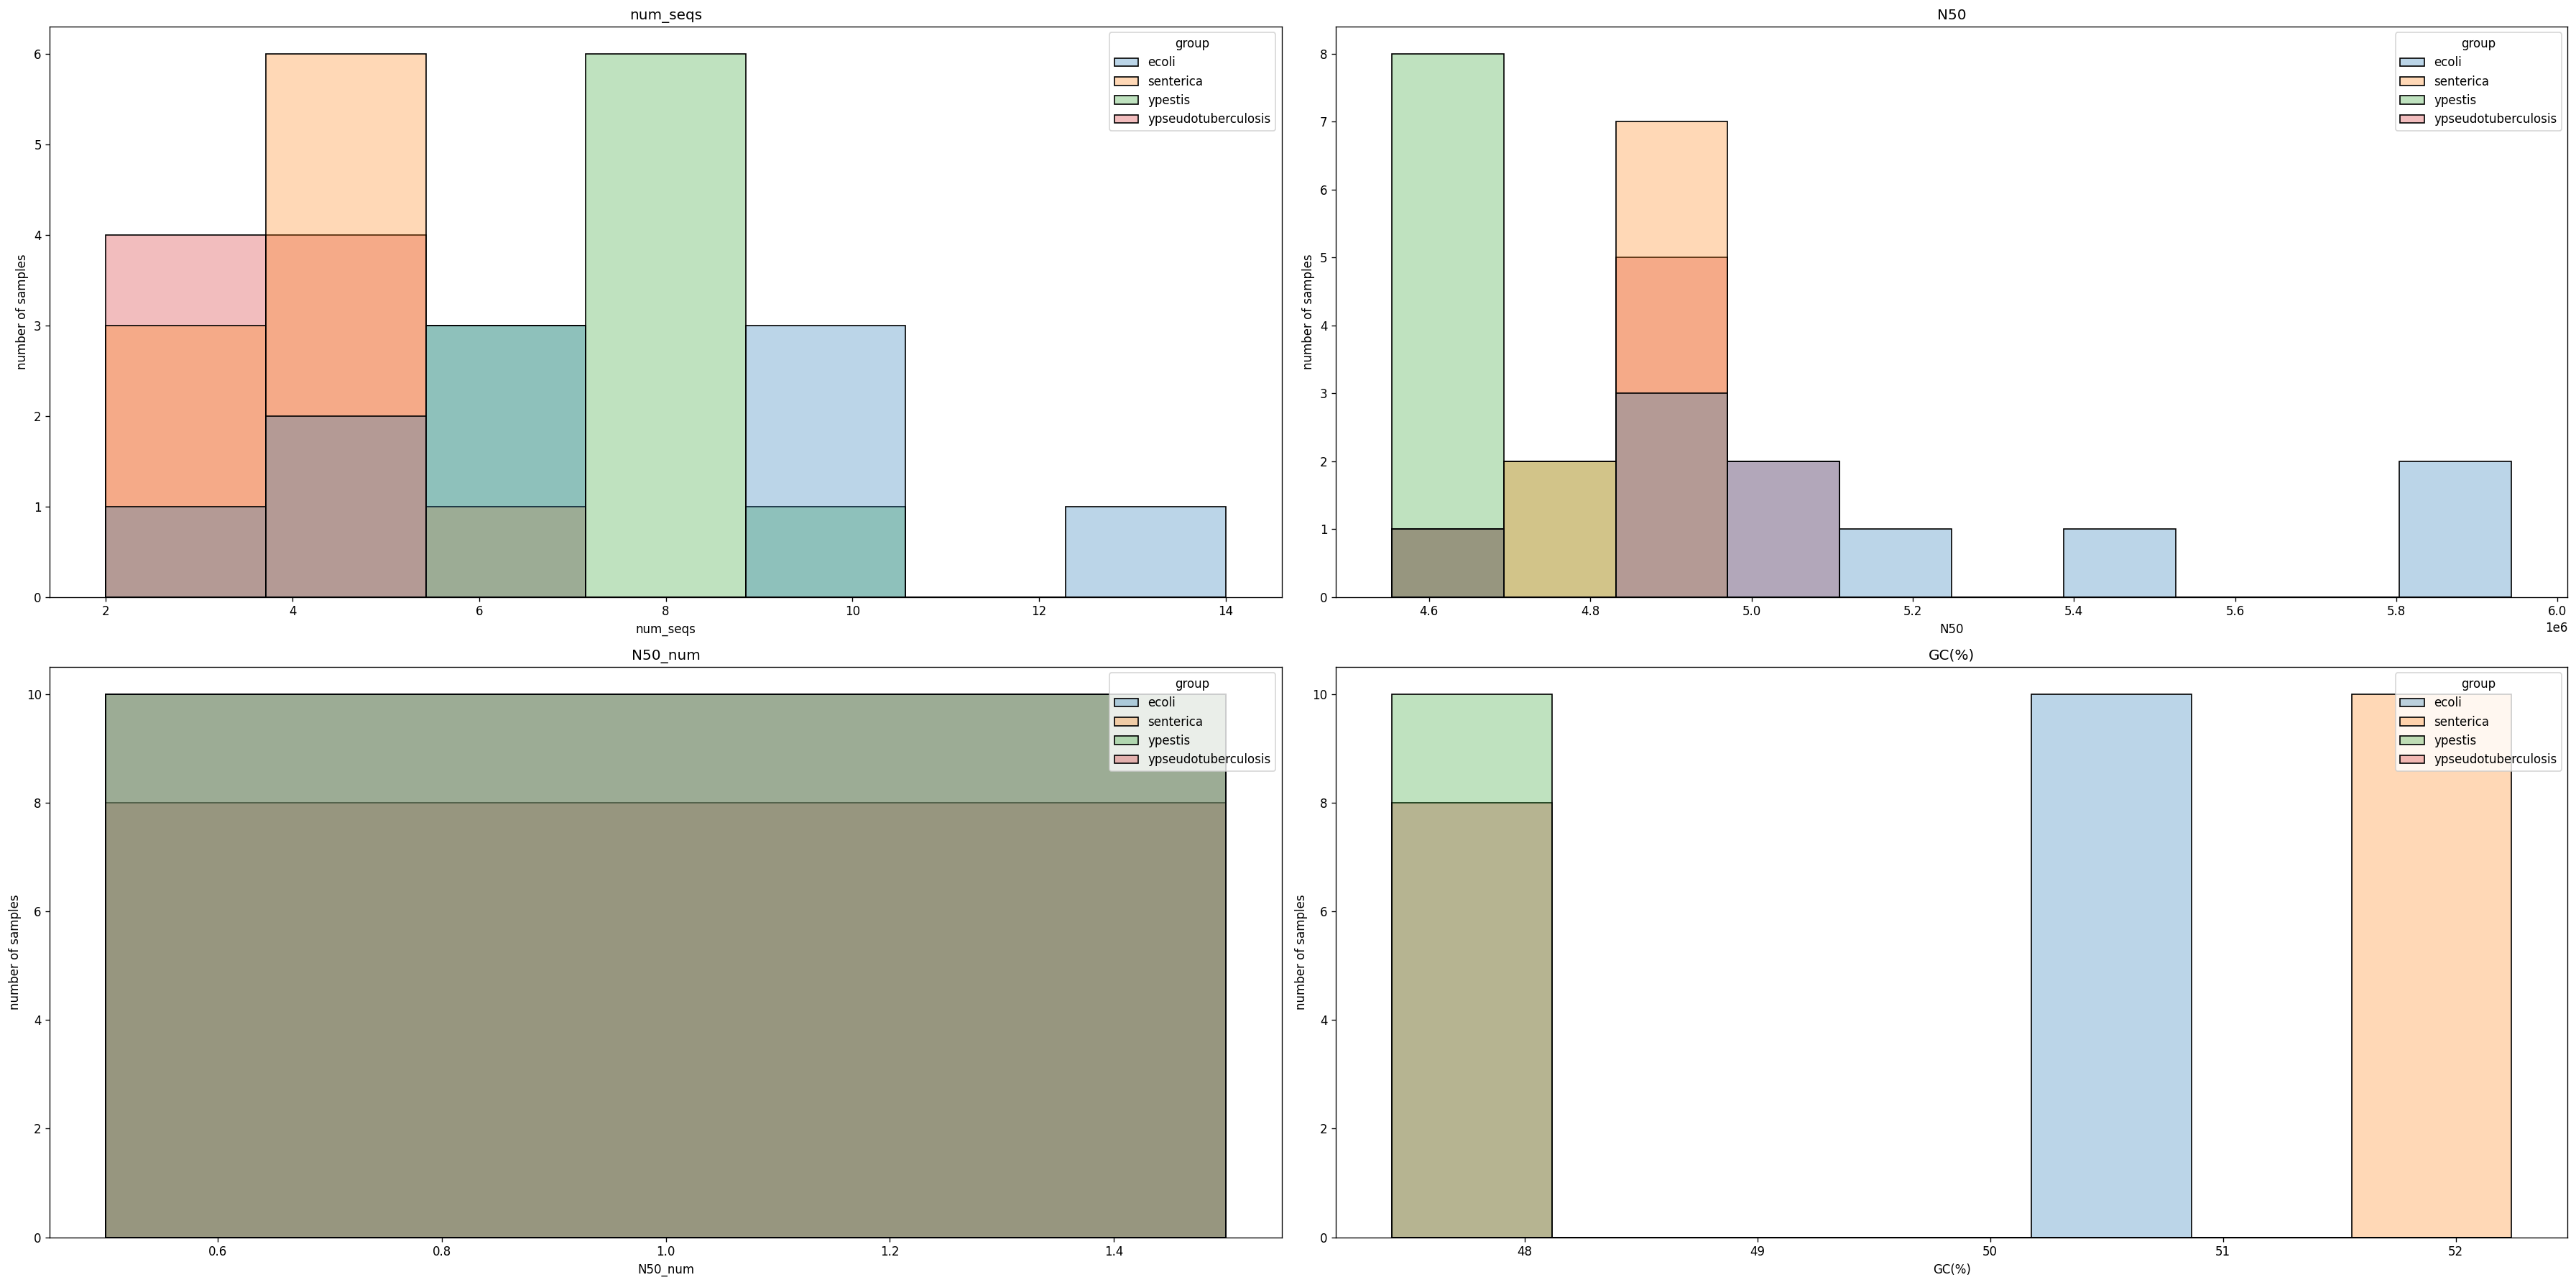

In [5]:
if HAS_GROUPS:
    qc_df['group'] = qc_df['file'].str.split('_').str[0]

fig, axs = plt.subplots(nrows, ncols, figsize=(30, 15), dpi=120)
plt.subplots_adjust(bottom=0.1,
                    top=1.1)
axs = axs.ravel()

for num, metric in enumerate(target_metrics):
    ax = axs[num]
    plot_kwargs = {
        'data': qc_df,
        'x': metric,
        'ax': ax
    }
    if HAS_GROUPS:
        plot_kwargs['hue'] = 'group'
        plot_kwargs['multiple'] = 'layer'
        plot_kwargs['alpha'] = 0.3
    
    sns.histplot(**plot_kwargs)
    ax.set_xlabel(metric)
    ax.set_ylabel('number of samples')
    ax.set_title(metric)
plt.tight_layout()


# Annotate cds
For example, by using this kind of scripts:

```python
import os 

work_path = 'codon_usage/test_data'
outdir = 'codon_usage/prokka'
for fasta in os.listdir(work_path):
    command = f'prokka {work_path}/{fasta} --outdir {outdir}/{fasta[:-6]} --cpus 10 --prefix {fasta[:-6]}'
    os.system(command)

```
and then:

```sh
$ cp prokka/*/*.ffn ffn/
```

One more QC test:
```sh
$ grep -c "^>" *.ffn > cds.txt
```

Text(0, 0.5, 'number of strains')

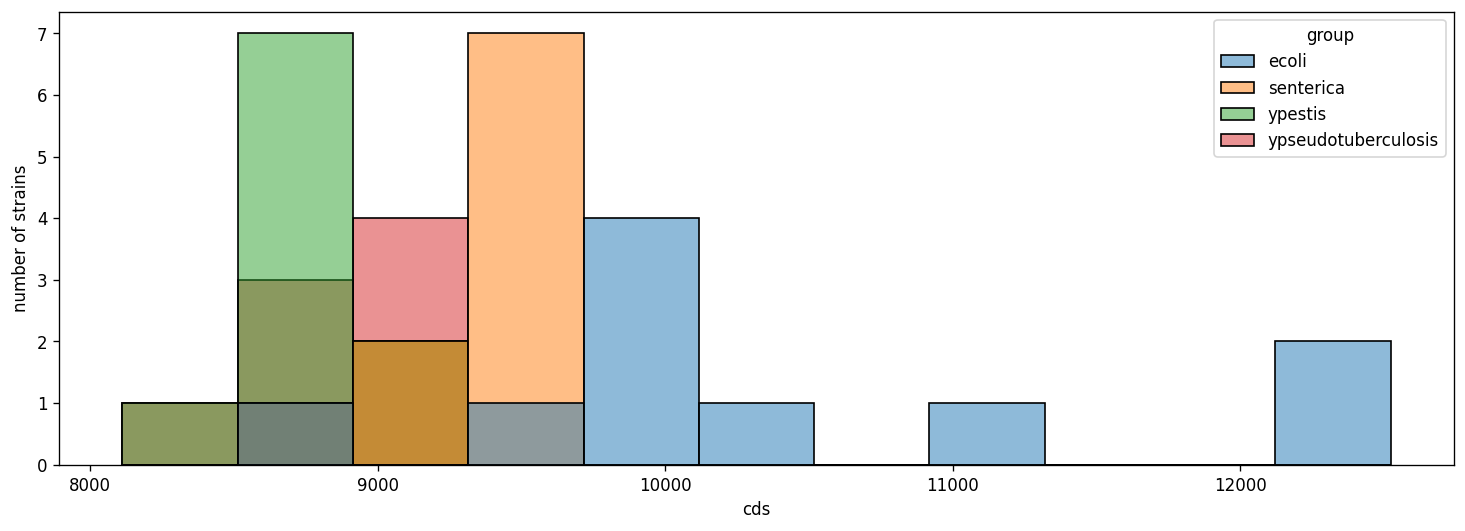

In [ ]:
cds = pd.read_csv(f'{WORKDIR}/cds.txt', sep=':', header=None, names=['file','cds'])

if HAS_GROUPS:
    cds['group'] = cds['file'].str.split('_').str[0]
else:
    cds['group'] = 'all'

plt.figure(figsize=(15, 5), dpi=120)
sns.histplot(data=cds, x='cds', hue='group')
plt.xlabel('cds')
plt.ylabel('number of strains')

# Codon usage

To calculate codon usage frequensy use emboss cusp. It will generate tables, that will be analize here.
To use emboss cusp for all samples use something like this:

``` python
import os

work_path = '/home/p/code/codon_usage/ffn'
outdir = '/home/p/code/codon_usage/freq'

for ffn in os.listdir(work_path):
    command = f'cusp -sequence {work_path}/{ffn} -outfile {outdir}/{ffn[:-4]}.tsv'
    os.system(command)
```

In [261]:
def cusp_res_parser(strain_codon_usage, group, strain_name):
    frequency_strain_df = (strain_codon_usage.rename(columns={'Frequency':strain_name})
                           .set_index('Codon')
                           .T.drop(['AA', 'Fraction', 'Number']))
    
    frequency_strain_df['group'] = group

    return frequency_strain_df

In [262]:
frequencies_df = pd.DataFrame()

for strain in os.listdir(f'{WORKDIR}/freq'):
    cur_path = f'{WORKDIR}/freq/{strain}'

    if HAS_GROUPS:
        group = strain.split('_')[0]
    else:
        group = ''
    
    strain_name = os.path.splitext(os.path.split(cur_path)[1])[0]
    strain_codon_usage = pd.read_csv(cur_path, comment='#', sep=r'\s+',
                                     names=['Codon','AA','Fraction','Frequency','Number'])
    
    cur_freq_df = cusp_res_parser(strain_codon_usage, group, strain_name)
    frequencies_df = pd.concat([frequencies_df, cur_freq_df])

In [263]:
frequencies_df

Codon,GCA,GCC,GCG,GCT,TGC,TGT,GAC,GAT,GAA,GAG,...,GTC,GTG,GTT,TGG,TAC,TAT,TAA,TAG,TGA,group
ypestis_CMCCK110001,21.055,26.777,23.761,19.633,4.794,5.648,14.508,36.447,34.648,20.543,...,15.474,22.551,19.093,13.648,10.207,19.759,1.901,0.56,1.094,ypestis
senterica_ATCC_13311,12.943,28.981,42.539,12.807,6.716,4.938,20.02,31.722,35.263,20.484,...,18.265,24.918,15.716,15.259,11.403,17.137,2.058,0.389,1.189,senterica
ypestis_Shasta,20.959,26.867,23.818,19.712,4.776,5.66,14.475,36.584,34.541,20.519,...,15.531,22.555,19.077,13.646,10.122,19.726,1.902,0.568,1.085,ypestis
ypestis_A1122,21.044,26.889,23.781,19.769,4.763,5.647,14.447,36.721,34.547,20.47,...,15.533,22.656,19.073,13.59,10.147,19.747,1.915,0.564,1.059,ypestis
ecoli_ATCC11775,20.676,25.527,32.812,15.625,6.317,5.267,19.21,32.233,39.29,18.092,...,15.171,25.911,18.448,15.446,12.077,16.234,2.121,0.309,1.14,ecoli
ypestis_FDAARGOS_601,21.18,26.742,23.751,19.634,4.78,5.579,14.61,36.291,34.645,20.588,...,15.479,22.536,19.058,13.581,10.151,19.722,1.923,0.579,1.152,ypestis
ypseudotuberculosis_FDAARGOS_342,20.542,27.099,23.637,19.8,4.721,5.728,14.391,37.248,34.143,20.269,...,15.493,22.659,18.946,13.925,9.923,19.573,1.892,0.609,1.095,ypseudotuberculosis
senterica_LT2,12.999,29.167,42.336,12.728,6.719,4.917,20.299,31.511,35.106,20.66,...,18.237,25.18,15.48,15.304,11.524,17.033,2.035,0.392,1.199,senterica
ecoli_UTI89,20.913,25.425,32.704,15.742,6.281,5.284,19.132,32.352,39.205,18.162,...,15.09,25.864,18.445,15.425,12.061,16.36,2.096,0.303,1.145,ecoli
ypestis_Dodson,20.93,26.891,23.793,19.703,4.805,5.725,14.293,36.658,34.494,20.41,...,15.535,22.588,19.006,13.66,10.078,19.779,1.907,0.579,1.111,ypestis


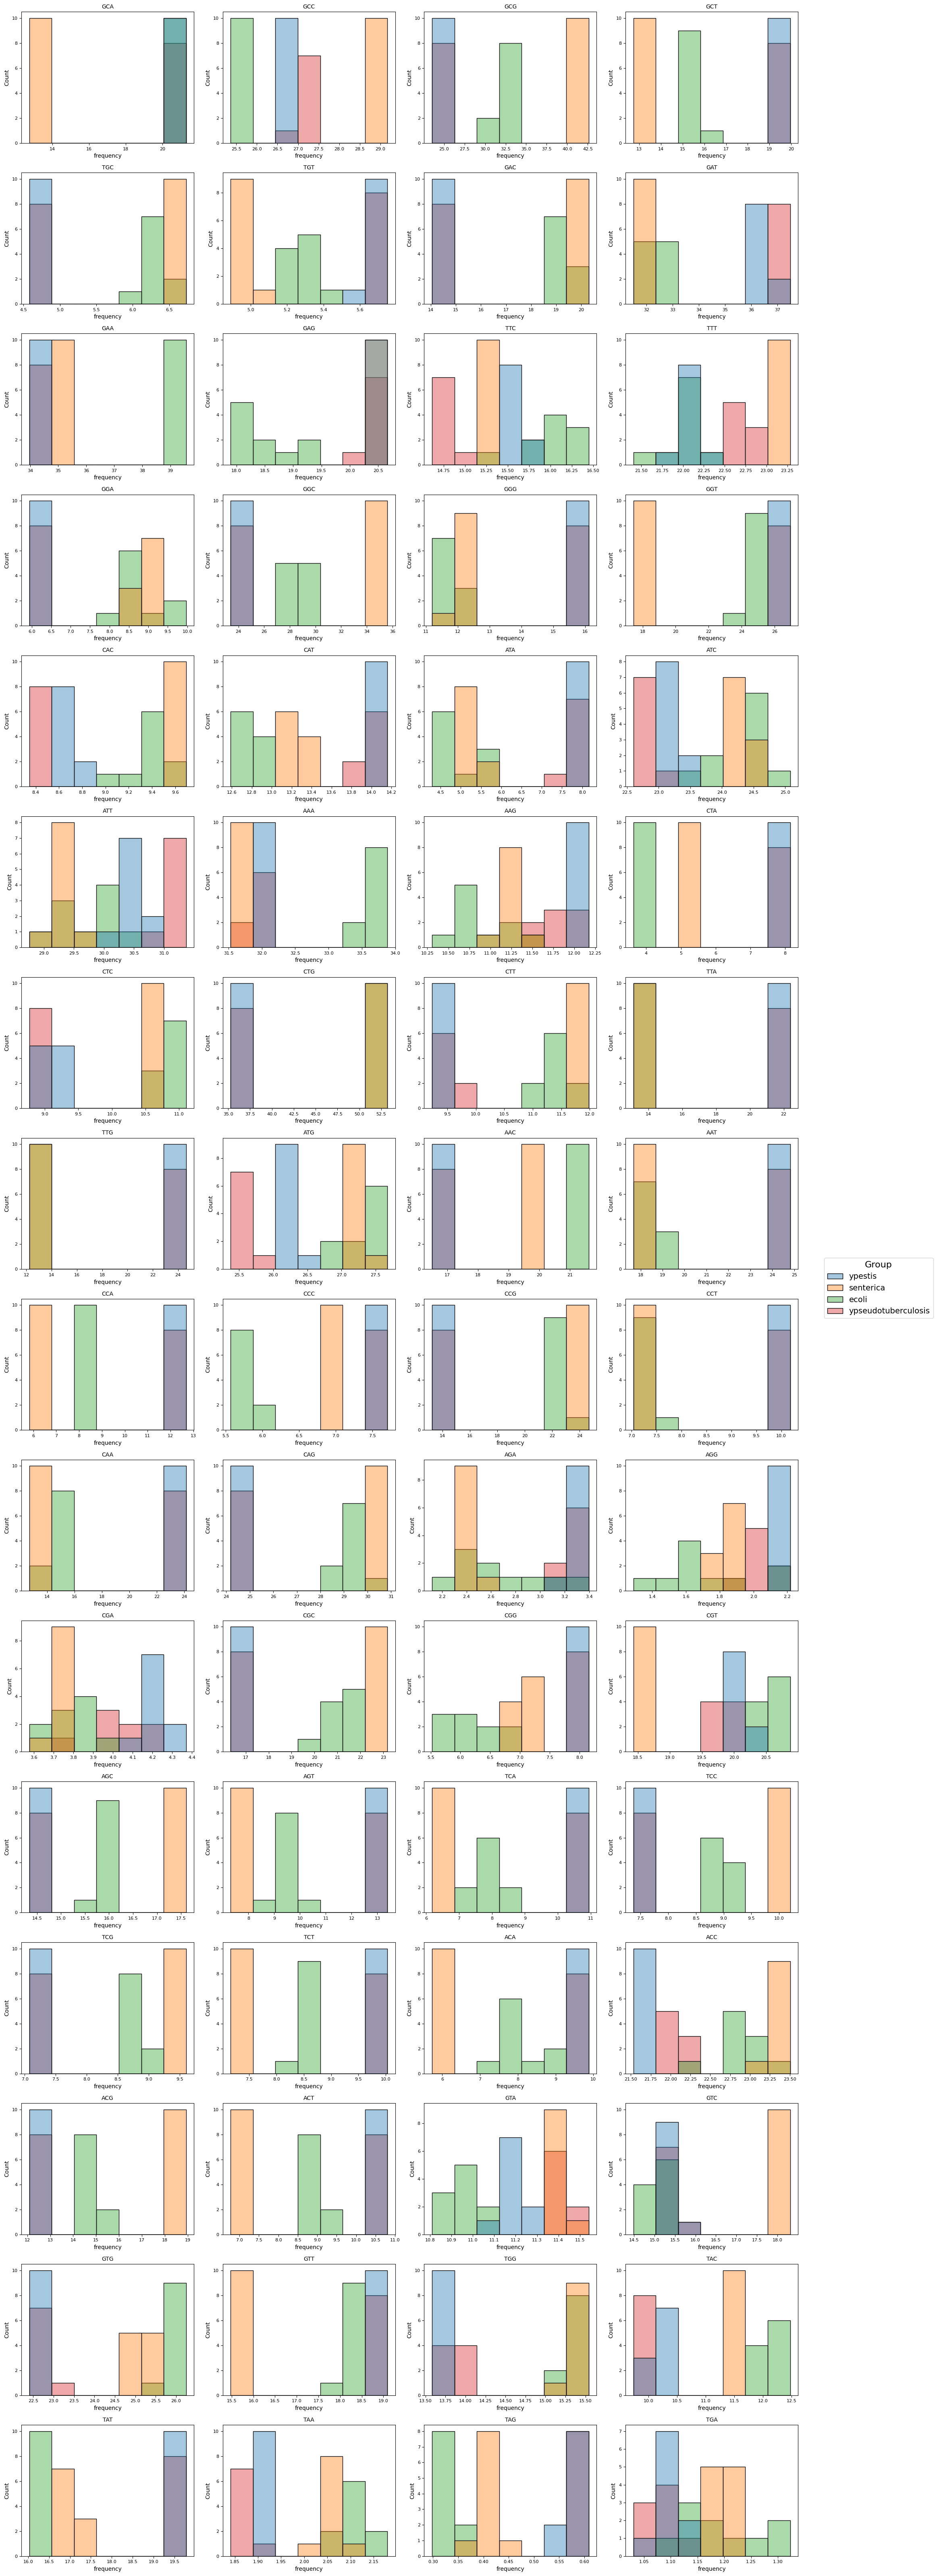

In [ ]:
fig, axs = plt.subplots(16, 4, figsize=(20, 4 * 16), dpi=100)
axs = axs.ravel()

for num, codon in enumerate(frequencies_df.columns.drop('group')):
    ax = axs[num]
    sns.histplot(data=frequencies_df, x=codon, ax=ax, hue='group', alpha=0.4, legend=(num == 0))


    if num == 0 and ax.legend_ is not None:
        handles = ax.legend_.legend_handles
        labels = [t.get_text() for t in ax.legend_.texts]
    

    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_xlabel('frequency')
    ax.set_title(codon, fontsize=10)
    ax.tick_params(labelsize=8)

if handles is not None and labels is not None:
    fig.legend(
        handles,
        labels,
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        title='Group',
        fontsize=14,
        title_fontsize=16
    )
    
plt.tight_layout()



In [21]:
scaler = StandardScaler()
X = frequencies_df.drop('group', axis=1).astype(float)
X_scaled = scaler.fit_transform(X)
y = frequencies_df['group'].reset_index(drop=True)
scaled_df = frequencies_df.drop('group', axis=1).copy()
scaled_df[scaled_df.columns] = X_scaled

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)
pca_df = pd.DataFrame(columns=['PC1','PC2'], data=X_pca)
pca_df['group'] = frequencies_df['group'].reset_index(drop=True).astype(str)
pca_df.index = frequencies_df.index
explaned_ratio = pca.explained_variance_ratio_
print(f'Total explaned ratio:{sum(explaned_ratio)}')

Total explaned ratio:0.9443046971865053


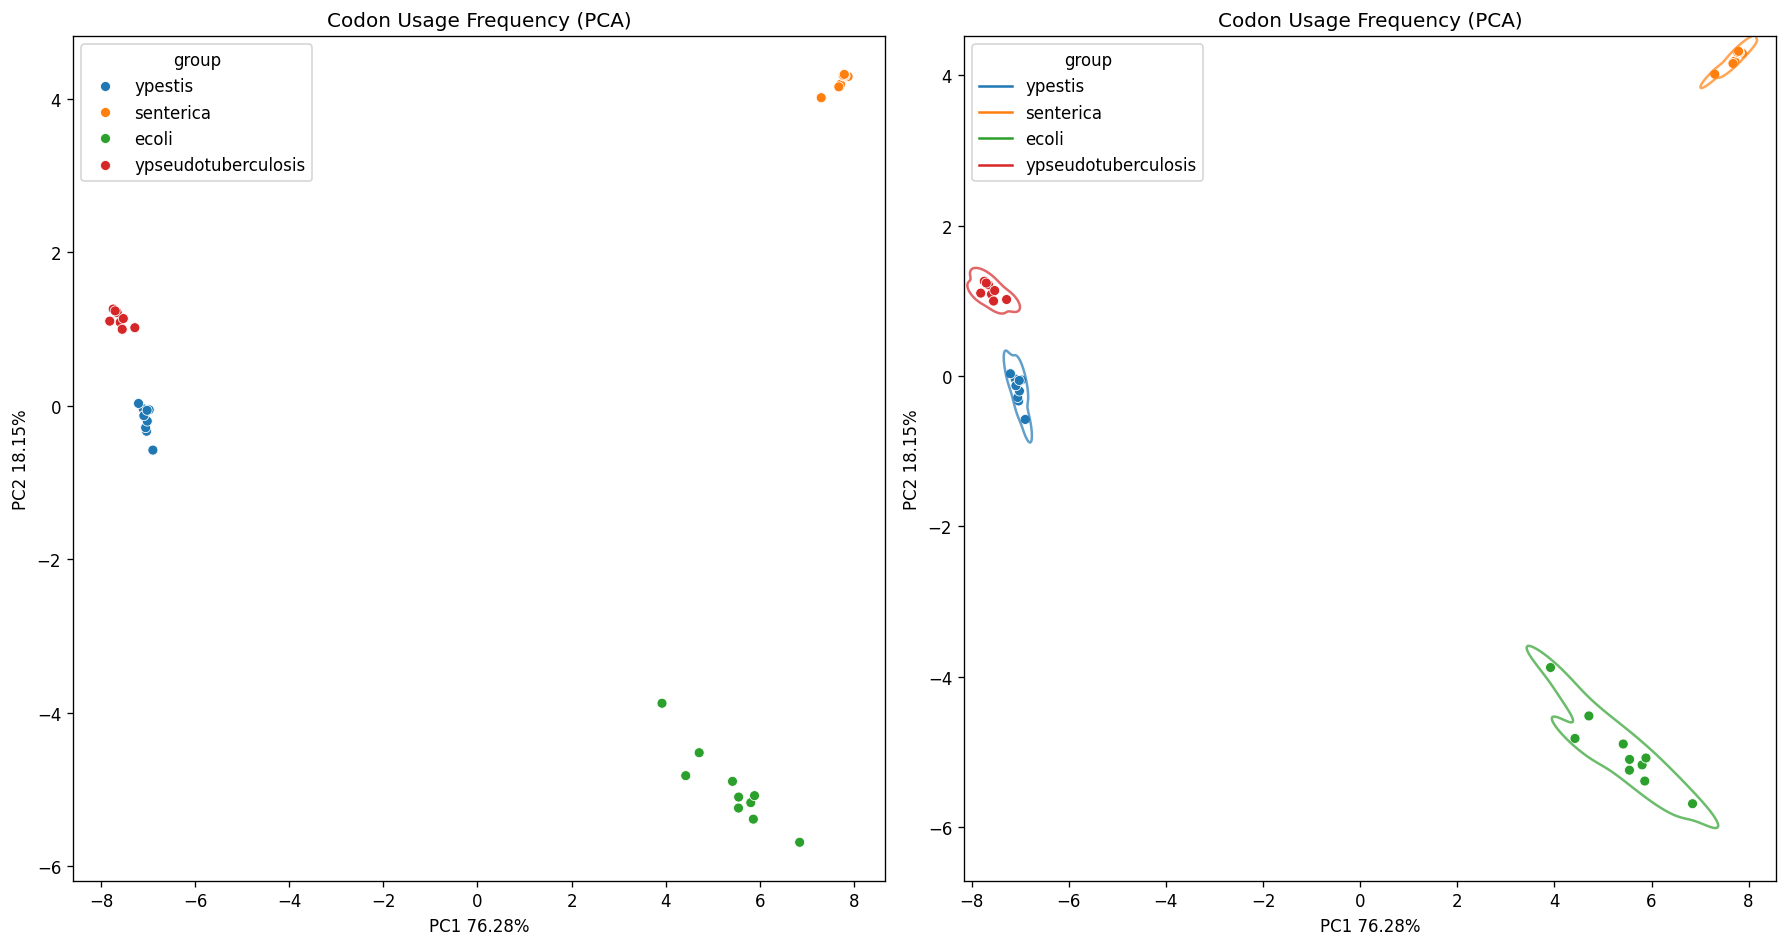

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 8), dpi=120)
axs = axs.ravel()

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', ax=axs[0])
axs[0].set_xlabel(f'PC1 {explaned_ratio[0]:.2%}')
axs[0].set_ylabel(f'PC2 {explaned_ratio[1]:.2%}')
axs[0].set_title('Codon Usage Frequency (PCA)')

sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', ax=axs[1])
sns.kdeplot(data=pca_df, x='PC1', y='PC2', hue='group', levels=1, alpha=0.7, thresh=0.01, ax=axs[1])
axs[1].set_xlabel(f'PC1 {explaned_ratio[0]:.2%}')
axs[1].set_ylabel(f'PC2 {explaned_ratio[1]:.2%}')
axs[1].set_title('Codon Usage Frequency (PCA)')

plt.tight_layout()


In [ ]:
tsne_res = TSNE(n_components=2, perplexity=30, max_iter=5000).fit_transform(frequencies_df.drop('group', axis=1))
tsne_df = pd.DataFrame(columns=['TSNE1','TSNE2'], data=tsne_res)
tsne_df['group'] = frequencies_df['group'].reset_index(drop=True).astype(str)
tsne_df.index = frequencies_df.index

Text(0.5, 1.0, 'Codon Usage Frequency (t-SNE)')

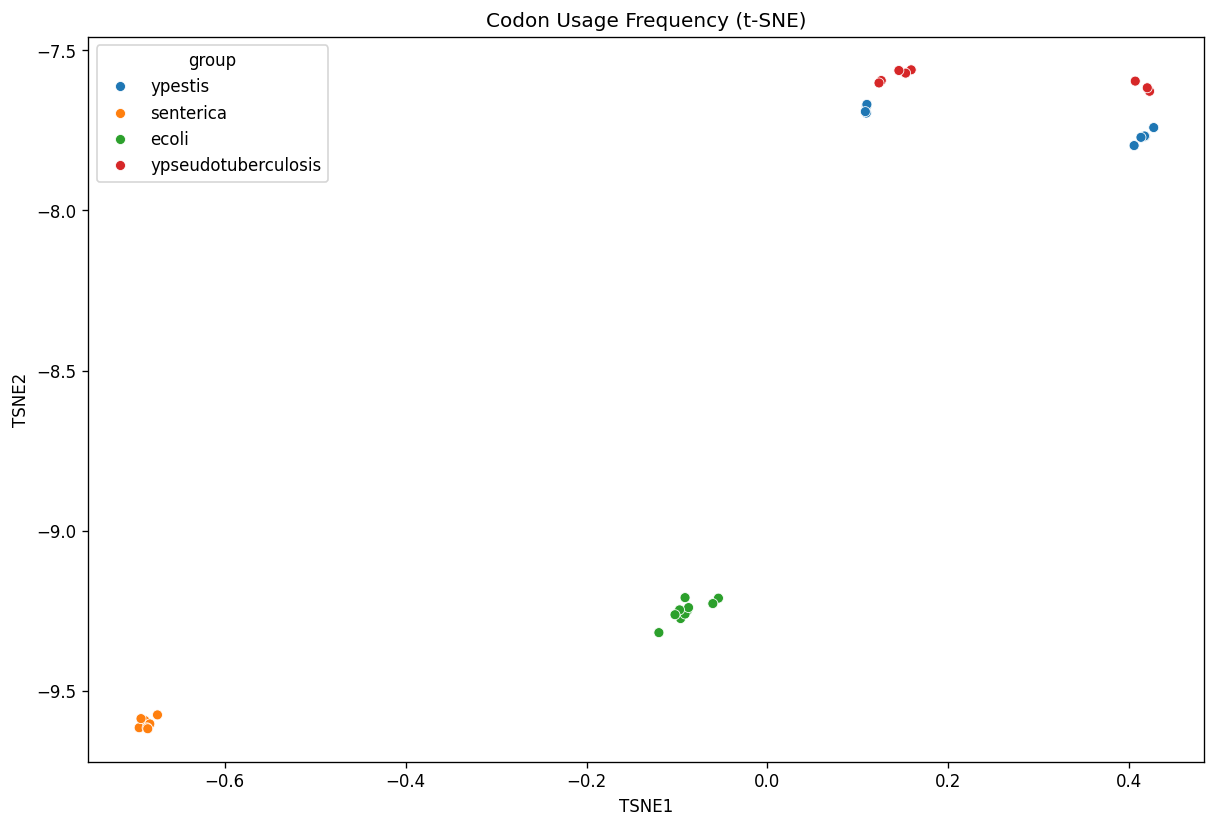

In [63]:
plt.figure(figsize=(12,8), dpi=120)
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='group')
plt.title('Codon Usage Frequency (t-SNE)')

# RSCU

In [151]:
def get_codons_rscu(sample_table, sample_name):

    sample_table = sample_table[sample_table['AA'] != '*'].copy()
    sample_table['AA_total'] = sample_table.groupby('AA')['Number'].transform('sum')
    sample_table['AA_ncodons'] = sample_table.groupby('AA')['Codon'].transform('count')

    sample_table['RSCU'] = (sample_table['Number'] * sample_table['AA_ncodons']) / sample_table['AA_total']

    rscu_sum = sample_table.groupby('AA')['RSCU'].sum()
    n_codons = sample_table.groupby('AA')['Codon'].count()
    check = np.isclose(rscu_sum, n_codons)

    if not check.all():
        raise ValueError(f"RSCU check failed")    
    
    sample_table =  sample_table.set_index('Codon')
    res = sample_table['RSCU'].to_frame().T
    res.index = [sample_name]
    return res

def calculate_rscu(cur_codon_amount, synonymous_codons_amount, n_synonymous_codons):
    '''
    This function does not use anywhere. But it stores a formula that is used to calculate RSCU
    '''
    return (cur_codon_amount * n_synonymous_codons)/ synonymous_codons_amount

In [152]:
rscu_df  = pd.DataFrame()

for strain in os.listdir(f'{WORKDIR}/freq'):
    strain_name = os.path.splitext(strain)[0]
    strain_df = pd.read_csv(f'{WORKDIR}/freq/{strain}', comment='#', sep=r'\s+',
                                     names=['Codon','AA','Fraction','Frequency','Number'])
    strain_rscu = get_codons_rscu(strain_df, strain_name)
    rscu_df = pd.concat([rscu_df, strain_rscu])

if HAS_GROUPS:
    rscu_df['group'] = rscu_df.index.str.split('_').str[0]
else:
    rscu_df['group'] = 'all'


In [154]:
tsne_rscu = TSNE(n_components=2, perplexity=30, max_iter=5000)
rscu_tsne = tsne_rscu.fit_transform(rscu_df.drop('group', axis=1))
rscu_tsne_df = pd.DataFrame(columns=['TSNE1','TSNE2'], data=rscu_tsne, index=rscu_df.index)
rscu_tsne_df['group'] = rscu_df['group']

In [155]:
rscu_pca = PCA(n_components=2)
rscu_scaler = StandardScaler()

y_rscu = rscu_df['group']
X_rscu = rscu_scaler.fit_transform(rscu_df.drop('group', axis=1))
rscu_df_scaled = pd.DataFrame(index=rscu_df.index, columns=rscu_df.columns[:-1], data=X_rscu)

rscu_pca_res = rscu_pca.fit_transform(rscu_df_scaled)
rscu_pca_df = pd.DataFrame(columns=['PC1','PC2'], data=rscu_pca_res, index=rscu_df.index)
rscu_pca_df['group'] = y_rscu

rscu_explained_ratio = rscu_pca.explained_variance_ratio_
print(f'Total explaned ratio:{sum(rscu_explained_ratio)}')

Total explaned ratio:0.9559123447656594


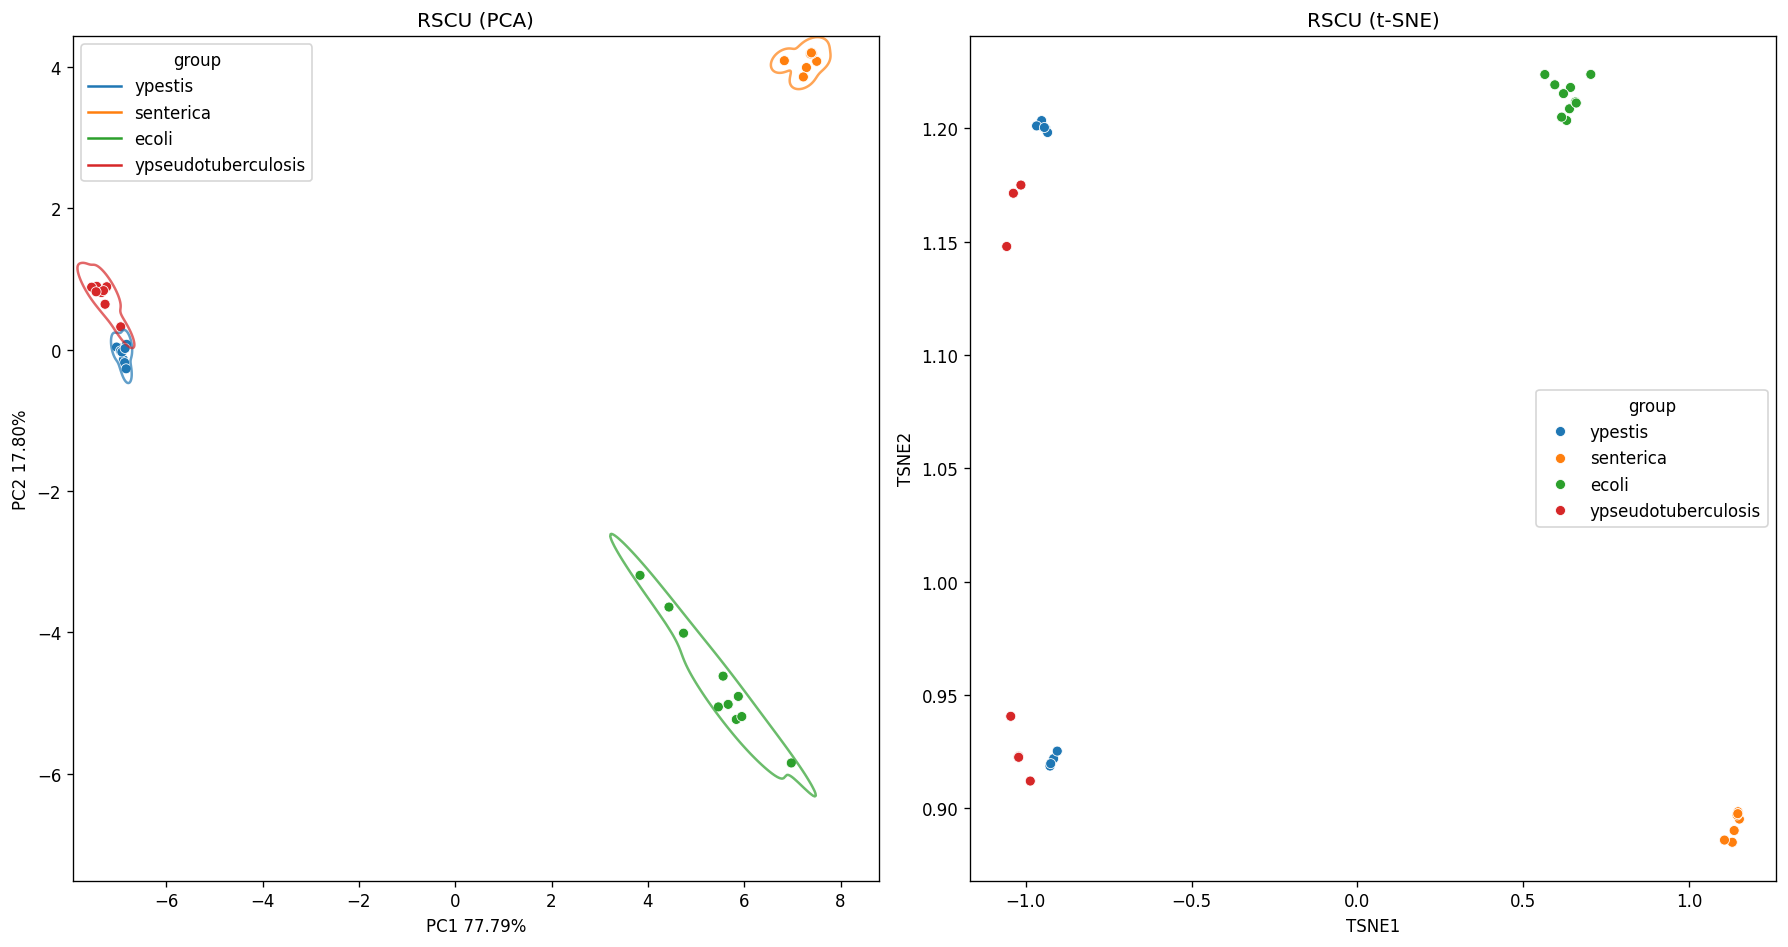

In [156]:
fig, axs = plt.subplots(1, 2, figsize=(15, 8), dpi=120)
axs = axs.ravel()

sns.scatterplot(data=rscu_pca_df, x='PC1', y='PC2', hue='group', ax=axs[0])
sns.kdeplot(data=rscu_pca_df, x='PC1', y='PC2', hue='group', levels=1, alpha=0.7, thresh=0.01, ax=axs[0]) # comment this line to disable kde  
axs[0].set_xlabel(f'PC1 {rscu_explained_ratio[0]:.2%}')
axs[0].set_ylabel(f'PC2 {rscu_explained_ratio[1]:.2%}')
axs[0].set_title('RSCU (PCA)')

sns.scatterplot(data=rscu_tsne_df, x='TSNE1', y='TSNE2', hue='group', ax=axs[1])
axs[1].set_title('RSCU (t-SNE)')

plt.tight_layout()


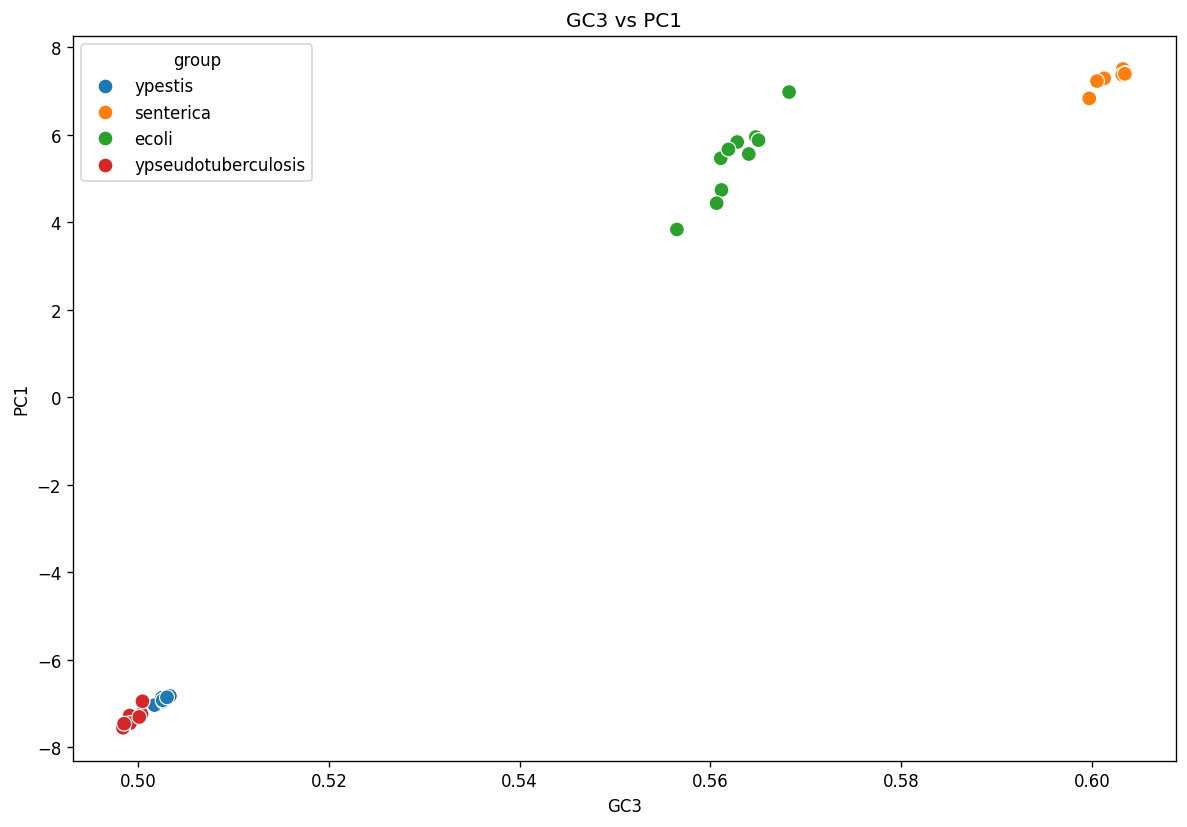

In [157]:
codons = rscu_df.drop('group', axis=1).columns
gc3_pc1_df = rscu_pca_df[['PC1', 'group']]

gc3 = []
for codon in codons:
    if codon[2] in ["G","C"]:
        gc3.append(1)
    else:
        gc3.append(0)

gc3_map = dict(zip(codons, gc3))

gc3_pc1_df["GC3"] = (
    rscu_df[codons] * [gc3_map[c] for c in codons]
).sum(axis=1) / rscu_df[codons].sum(axis=1)

plt.figure(figsize=(10,7), dpi=120)
sns.scatterplot(data=gc3_pc1_df, x="GC3", y="PC1", hue="group", s=80)
plt.xlabel("GC3")
plt.ylabel("PC1")
plt.title("GC3 vs PC1")

plt.tight_layout()

Text(188.66666666666669, 0.5, 'Groups')

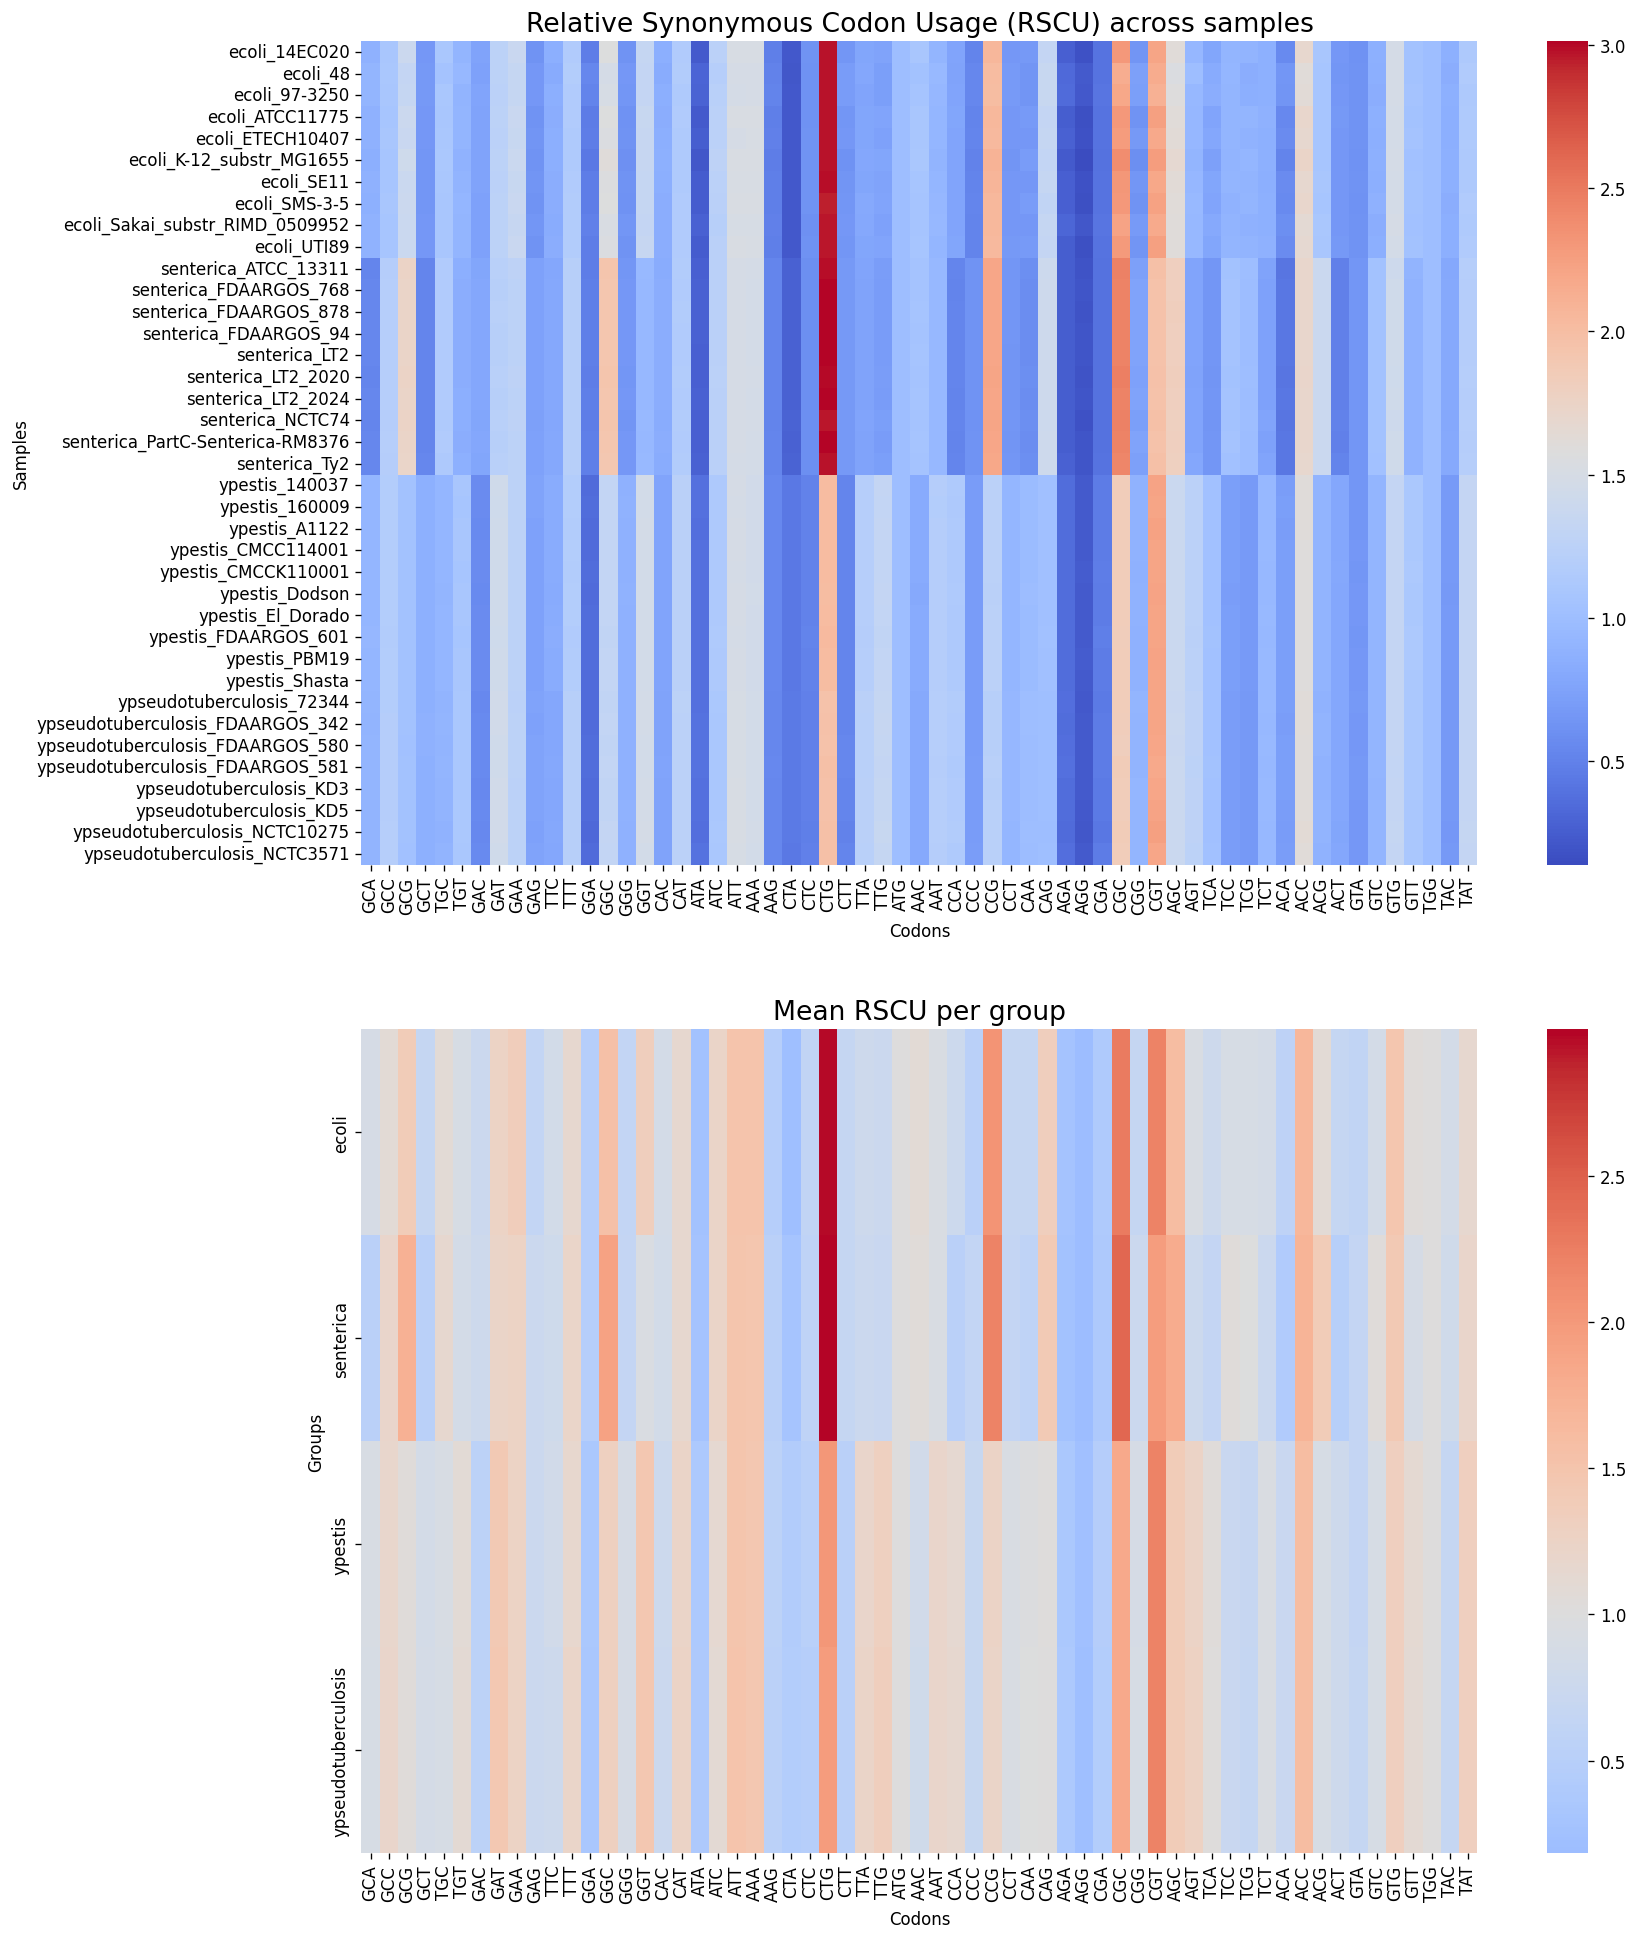

<Figure size 1680x1200 with 0 Axes>

In [171]:
fig, axs = plt.subplots(2, 1, figsize=(15, 20), dpi=120)
axs = axs.ravel()

plt.figure(figsize=(14,10), dpi=120)
sns.heatmap(rscu_df.drop('group', axis=1).sort_index(), xticklabels=True, yticklabels=True, ax=axs[0], cmap="coolwarm")
axs[0].set_title("Relative Synonymous Codon Usage (RSCU) across samples", fontsize=16)
axs[0].set_xlabel("Codons")
axs[0].set_ylabel("Samples")

mean_rscu = rscu_df.groupby("group").mean()

sns.heatmap(mean_rscu, cmap="coolwarm", center=1, ax=axs[1])
axs[1].set_title("Mean RSCU per group", fontsize=16)
axs[1].set_xlabel("Codons")
axs[1].set_ylabel("Groups")

# Effective Number of Codons (ENC)

In [226]:
def calculate_enc(sample_table):
    df = sample_table.loc[sample_table['AA'] != '*'].copy()

    f_by_family = {2: [], 3: [], 4: [], 6: []}

    for aa, aa_df in df.groupby('AA'):
        n = aa_df.shape[0]
        
        if n not in f_by_family:
            continue

        total = aa_df['Number'].sum()
        
        p = aa_df['Number'] / total
 
        f = np.sum(p ** 2)

        f_by_family[n].append(f)

    F2 = np.mean(f_by_family[2])
    F3 = np.mean(f_by_family[3])
    F4 = np.mean(f_by_family[4])
    F6 = np.mean(f_by_family[6])

    enc = 2 + (9 / F2) + (1 / F3) + (5 / F4) + (3 / F6)

    return enc

In [260]:
enc_df = pd.DataFrame()

for strain in os.listdir(f'{WORKDIR}/freq'):
    strain_name = os.path.splitext(strain)[0]
    strain_df = pd.read_csv(f'{WORKDIR}/freq/{strain}', comment='#', sep=r'\s+',
                                     names=['Codon','AA','Fraction','Frequency','Number'])

    strain_enc = calculate_enc(strain_df)

    enc_df = pd.concat([enc_df, pd.DataFrame({'strain': [strain_name], 'enc': [strain_enc]})])

enc_df = enc_df.set_index('strain')
enc_df['group'] = enc_df.index.str.split('_').str[0]
enc_df

,enc,group
strain,,
ypestis_CMCCK110001,53.255686,ypestis
senterica_ATCC_13311,48.042250,senterica
ypestis_Shasta,53.224132,ypestis
ypestis_A1122,53.127889,ypestis
ecoli_ATCC11775,49.256459,ecoli
ypestis_FDAARGOS_601,53.294154,ypestis
ypseudotuberculosis_FDAARGOS_342,53.173522,ypseudotuberculosis
senterica_LT2,48.037729,senterica
ecoli_UTI89,49.432558,ecoli


<Axes: xlabel='group', ylabel='enc'>

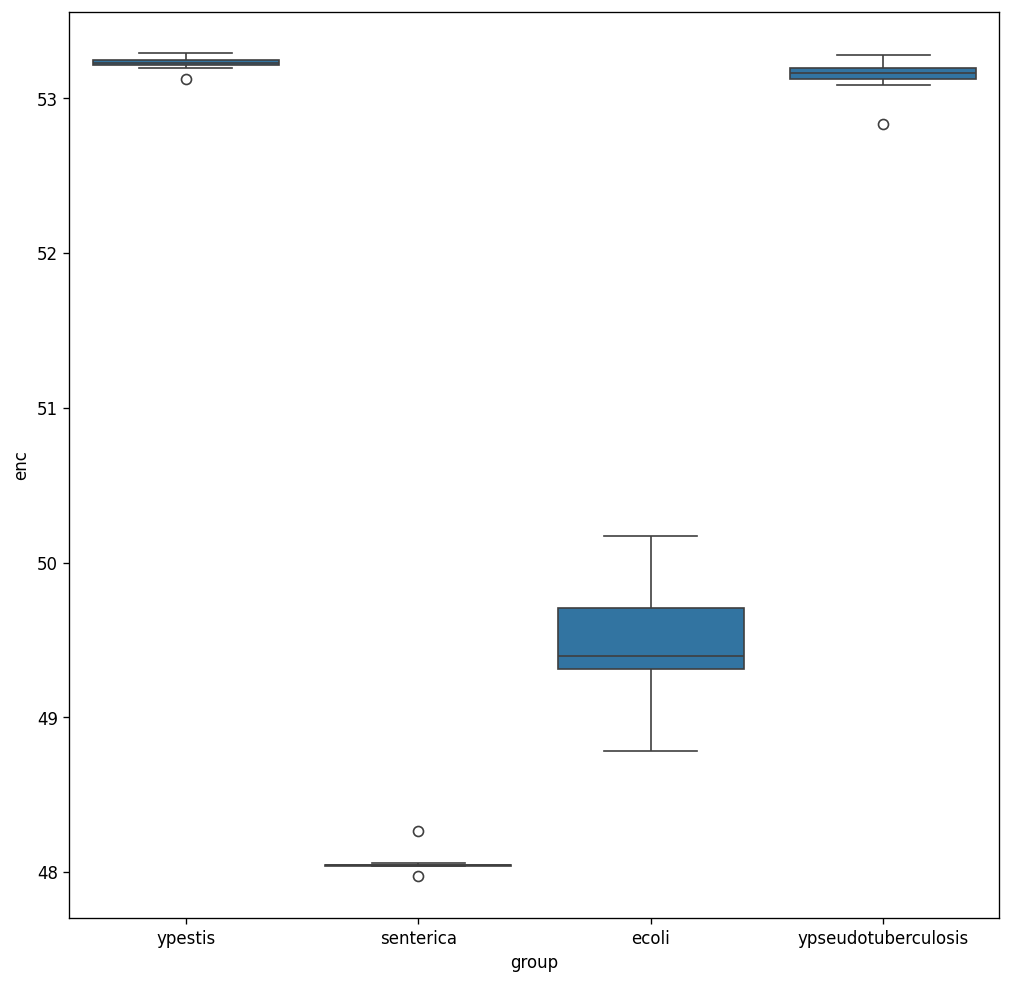

In [259]:
plt.figure(figsize=(10,10), dpi=120)
sns.boxplot(data=enc_df, x="group", y="enc")

# Kmers
To calculate pairwise Mash distances using 21-mers:

```sh
$ mash sketch -k 21 -o ../kmers/genomes *.fasta
$ mash dist genomes.msh genomes.msh > mash.dist.tsv
```

In [105]:
mash_dist_df = pd.read_csv(f'{WORKDIR}/kmers/mash.dist.tsv', sep='\t', header=None, names=['g1', 'g2', 'dist', 'p', 'shared'])
mash_dist_df['g1'] = mash_dist_df['g1'].map(lambda x: Path(x).stem)
mash_dist_df['g2'] = mash_dist_df['g2'].map(lambda x: Path(x).stem)

dist_df = mash_dist_df.pivot(index='g1', columns='g2', values='dist')
dist_df = dist_df.combine_first(dist_df.T)
dist_df = dist_df.fillna(0.0)

dm = DistanceMatrix(dist_df.values, ids=dist_df.index)
ord_res = pcoa(dm, dimensions=2)
coords = ord_res.samples.iloc[:, :2].copy()
coords.columns = ['PCo1', 'PCo2']
coords['group'] = coords.index.str.split('_').str[0]

Text(0.5, 1.0, 'PCoA of Mash distances (k=21)')

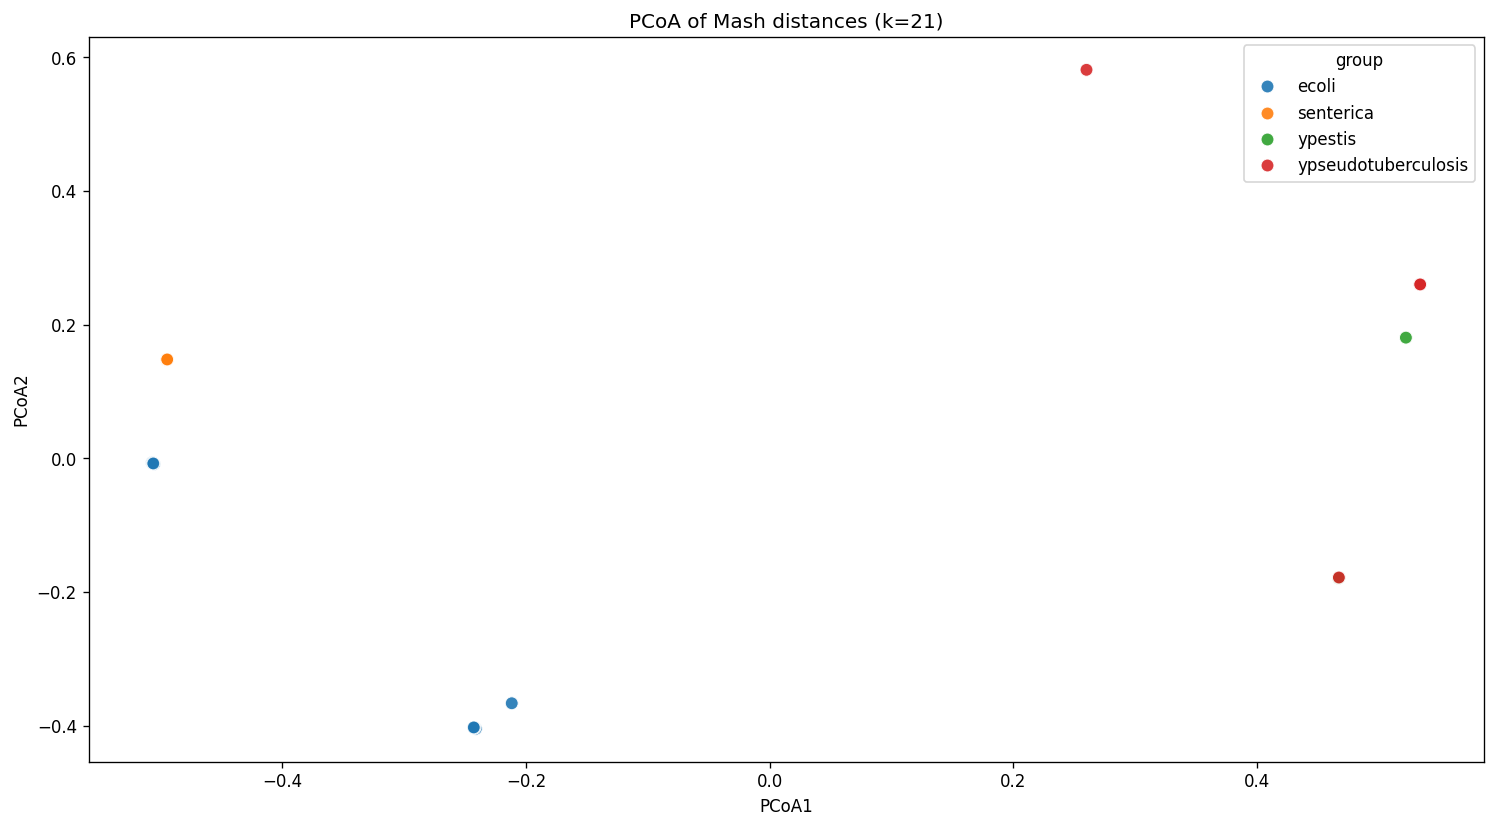

In [106]:
plt.figure(figsize=(15,8), dpi=120)
sns.scatterplot(data=coords, x='PCo1', y='PCo2', hue='group', s=60, alpha=0.9)
plt.xlabel(f'PCoA1')
plt.ylabel(f'PCoA2')
plt.title('PCoA of Mash distances (k=21)')